# Decision Tree


In [293]:
# 외부 모듈(라이브러리) 준비
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor

# 노트북 환경에서 그래프를 셀에 렌더링
%matplotlib inline

sns.set_style('whitegrid')

# 한글 폰트 설정 및 마이너스 부호 유니코드처리 해제
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

In [294]:
# 데이터 읽기
df = pd.read_csv('pandas/data/laptopData.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1273 non-null   float64
 1   Company           1273 non-null   object 
 2   TypeName          1273 non-null   object 
 3   Inches            1273 non-null   object 
 4   ScreenResolution  1273 non-null   object 
 5   Cpu               1273 non-null   object 
 6   Ram               1273 non-null   object 
 7   Memory            1273 non-null   object 
 8   Gpu               1273 non-null   object 
 9   OpSys             1273 non-null   object 
 10  Weight            1273 non-null   object 
 11  Price             1273 non-null   float64
dtypes: float64(2), object(10)
memory usage: 122.3+ KB


In [295]:
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


## 결측치 처리

이 데이터를 읽어보니 1303개의 행이 있고, 12개의 컬럼이 있는걸 확인할 수 있다. 그리고 각 데이터들은 모두 결측치를 갖고 있는데 결측치를 확인해보고 이를 어떻게 처리해야 할지 논리적인 방법론을 계획해보자.

In [296]:
# 결측치 처리 확인
df.isnull().sum()


Unnamed: 0          30
Company             30
TypeName            30
Inches              30
ScreenResolution    30
Cpu                 30
Ram                 30
Memory              30
Gpu                 30
OpSys               30
Weight              30
Price               30
dtype: int64

<Axes: >

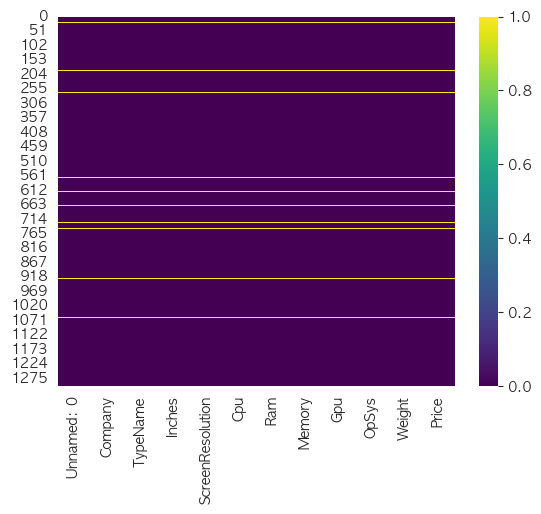

In [297]:
sns.heatmap(df.isnull(), cmap='viridis')

In [298]:
# 결측치를 확인해보니 삭제하는게 최고의 방법인것 같다.
df_clean = df.dropna()  # 결측치 삭제
# 원본 데이터와 결측치 처리된 데이터 비교
print(f'원본 데이터: {df.shape}')
print(f'결측치 처리된 데이터: {df_clean.shape}')

원본 데이터: (1303, 12)
결측치 처리된 데이터: (1273, 12)


In [299]:
# 모든 문자열 컬럼들의 유니크값 확인하기
# 방법 1: nunique() 한 줄로 해결 (가장 간단)
df_unique = df_clean.select_dtypes('object').nunique().reset_index(name='unique_count').rename(columns={'index': 'column'})
df_unique


,column,unique_count
0,Company,19
1,TypeName,6
2,Inches,25
3,ScreenResolution,40
4,Cpu,118
5,Ram,10
6,Memory,40
7,Gpu,110
8,OpSys,9
9,Weight,189


In [300]:
df_clean['Inches'].unique()

array(['13.3', '15.6', '15.4', '14', '12', '17.3', '13.5', '12.5', '13',
       '18.4', '13.9', '11.6', '25.6', '35.6', '12.3', '27.3', '24',
       '33.5', '?', '31.6', '17', '15', '14.1', '11.3', '10.1'],
      dtype=object)

In [301]:
df_clean.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [302]:
# 데이터들에 불순한 데이터들이 있느것을 확인할 수 있다.. 이를 결측치로 변환후 
for col in df_clean.columns:
    df_clean[col] = df_clean[col].replace('?', np.nan)

# 결측치로 변환된 행들 삭제하기
df_clean = df_clean.dropna()
df_clean = df_clean.reset_index(drop=True)

# 필요없는 Unnamed: 0 컬럼 삭제
df_clean = df_clean.drop(columns=['Unnamed: 0'])
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1270 entries, 0 to 1269
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1270 non-null   object 
 1   TypeName          1270 non-null   object 
 2   Inches            1270 non-null   object 
 3   ScreenResolution  1270 non-null   object 
 4   Cpu               1270 non-null   object 
 5   Ram               1270 non-null   object 
 6   Memory            1270 non-null   object 
 7   Gpu               1270 non-null   object 
 8   OpSys             1270 non-null   object 
 9   Weight            1270 non-null   object 
 10  Price             1270 non-null   float64
dtypes: float64(1), object(10)
memory usage: 109.3+ KB


/var/folders/mf/j4fycs613vd1hddkf_1jbwkr0000gn/T/ipykernel_39954/3029415251.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[col] = df_clean[col].replace('?', np.nan)


In [303]:
df_clean['Inches'] = df_clean['Inches'].astype(float)
df_clean.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [304]:
df_clean['Ram'] = df_clean['Ram'].str.replace('GB', '')
df_clean['Weight'] = df_clean['Weight'].str.replace('kg', '')
df_clean['Ram'] = df_clean['Ram'].astype(float)
df_clean['Weight'] = df_clean['Weight'].astype(float)
df_clean.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8.0,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8.0,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8.0,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16.0,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8.0,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080


In [305]:
# 타겟 인코딩 적용할 컬럼 목록
target_enc_cols = ['Cpu', 'Gpu', 'Company', 'Memory', 'ScreenResolution']

for col in target_enc_cols:
    mean_map = df_clean.groupby(col)['Price'].mean()
    df_clean[col] = df_clean[col].map(mean_map)
    
    
df_clean.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,83340.499886,Ultrabook,13.3,89508.091200,76143.513600,8.0,38054.052000,93986.519400,macOS,1.37,71378.6832
1,83340.499886,Ultrabook,13.3,55339.804800,54815.529600,8.0,37721.440800,54490.947840,macOS,1.34,47895.5232
2,57214.371465,Notebook,15.6,61601.812946,49103.165351,8.0,65317.857528,60900.481116,No OS,1.86,30636.0000
3,83340.499886,Ultrabook,15.4,132872.194800,135195.336000,16.0,99331.961710,135195.336000,macOS,1.83,135195.3360
4,83340.499886,Ultrabook,13.3,89508.091200,102393.504000,8.0,65317.857528,102393.504000,macOS,1.37,96095.8080


In [306]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1270 entries, 0 to 1269
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1270 non-null   float64
 1   TypeName          1270 non-null   object 
 2   Inches            1270 non-null   float64
 3   ScreenResolution  1270 non-null   float64
 4   Cpu               1270 non-null   float64
 5   Ram               1270 non-null   float64
 6   Memory            1270 non-null   float64
 7   Gpu               1270 non-null   float64
 8   OpSys             1270 non-null   object 
 9   Weight            1270 non-null   float64
 10  Price             1270 non-null   float64
dtypes: float64(9), object(2)
memory usage: 109.3+ KB


In [307]:
df_clean = pd.get_dummies(df_clean, drop_first=True, dtype='i1')
df_clean.head()

,Company,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,Weight,Price,TypeName_Gaming,...,TypeName_Ultrabook,TypeName_Workstation,OpSys_Chrome OS,OpSys_Linux,OpSys_Mac OS X,OpSys_No OS,OpSys_Windows 10,OpSys_Windows 10 S,OpSys_Windows 7,OpSys_macOS
0,83340.499886,13.3,89508.091200,76143.513600,8.0,38054.052000,93986.519400,1.37,71378.6832,0,...,1,0,0,0,0,0,0,0,0,1
1,83340.499886,13.3,55339.804800,54815.529600,8.0,37721.440800,54490.947840,1.34,47895.5232,0,...,1,0,0,0,0,0,0,0,0,1
2,57214.371465,15.6,61601.812946,49103.165351,8.0,65317.857528,60900.481116,1.86,30636.0000,0,...,0,0,0,0,0,1,0,0,0,0
3,83340.499886,15.4,132872.194800,135195.336000,16.0,99331.961710,135195.336000,1.83,135195.3360,0,...,1,0,0,0,0,0,0,0,0,1
4,83340.499886,13.3,89508.091200,102393.504000,8.0,65317.857528,102393.504000,1.37,96095.8080,0,...,1,0,0,0,0,0,0,0,0,1


In [308]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1270 entries, 0 to 1269
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company               1270 non-null   float64
 1   Inches                1270 non-null   float64
 2   ScreenResolution      1270 non-null   float64
 3   Cpu                   1270 non-null   float64
 4   Ram                   1270 non-null   float64
 5   Memory                1270 non-null   float64
 6   Gpu                   1270 non-null   float64
 7   Weight                1270 non-null   float64
 8   Price                 1270 non-null   float64
 9   TypeName_Gaming       1270 non-null   int8   
 10  TypeName_Netbook      1270 non-null   int8   
 11  TypeName_Notebook     1270 non-null   int8   
 12  TypeName_Ultrabook    1270 non-null   int8   
 13  TypeName_Workstation  1270 non-null   int8   
 14  OpSys_Chrome OS       1270 non-null   int8   
 15  OpSys_Linux          

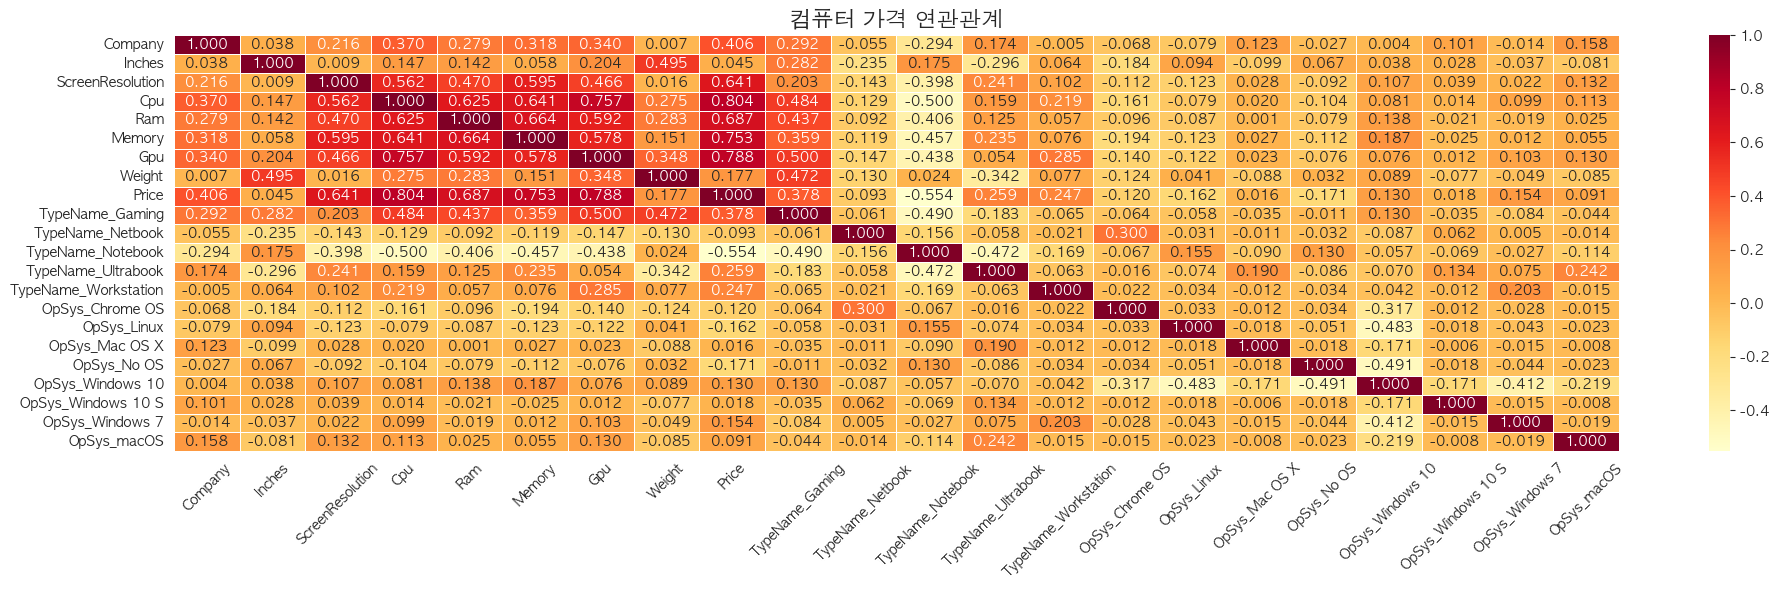

In [309]:
plt.figure(figsize=(20, 6))
sns.heatmap(df_clean.corr(), annot=True, fmt='.3f', cmap='YlOrRd', linewidths=0.5)
plt.title('컴퓨터 가격 연관관계', fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [310]:
# 데이터 분할
from sklearn.model_selection import train_test_split

X = df_clean.drop(['Price'], axis=1)
y = df_clean['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [311]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
# 데이터 스케일링
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

dtr = DecisionTreeRegressor(max_depth=5, random_state=42)
dtr.fit(X_train_s, y_train)

# ── 예측 ───────────────────────────────────────────────────
y_pred_train = dtr.predict(X_train_s)   # 학습 데이터 예측 (과적합 확인용)
y_pred_test  = dtr.predict(X_test_s)    # 테스트 데이터 예측

# ── 평가 ───────────────────────────────────────────────────
# MAE  : 평균 절대 오차 (단위: 원)
# RMSE : 평균 제곱근 오차 (MAE보다 큰 오류에 민감)
# R²   : 1에 가까울수록 좋음 (0.8 이상이면 양호)
print("=" * 45)
print(f"{'지표':10s} | {'Train':>12} | {'Test':>12}")
print("-" * 45)
print(f"{'MAE':10s} | {mean_absolute_error(y_train, y_pred_train):>12.2f} | {mean_absolute_error(y_test, y_pred_test):>12.2f}")
print(f"{'RMSE':10s} | {root_mean_squared_error(y_train, y_pred_train)**0.5:>12.2f} | {root_mean_squared_error(y_test, y_pred_test)**0.5:>12.2f}")
print(f"{'R²':10s} | {r2_score(y_train, y_pred_train):>12.4f} | {r2_score(y_test, y_pred_test):>12.4f}")
print("=" * 45)
print("→ Train R² >> Test R² 이면 과적합 (max_depth 줄이기)")

지표         |        Train |         Test
---------------------------------------------
MAE        |     10588.77 |      9110.53
RMSE       |       121.86 |       116.05
R²         |       0.8479 |       0.8369
→ Train R² >> Test R² 이면 과적합 (max_depth 줄이기)
